In [1]:
!pip install -U sympy
!pip install mido

from google.colab import drive
drive.mount('/content/drive/')


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 42.7 MB/s eta 0:00:00
  Attempting uninstall: sympy
    Found existing installation: sympy 1.13.1
    Uninstalling sympy-1.13.1:
      Successfully uninstalled sympy-1.13.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torch 2.6.0+cu124 requires nvidia-cublas-cu12==12.4.5.8; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cublas-cu12 12.5.3.2 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cuda-cupti-cu12==12.4.127; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cuda-cupti-cu12 12.5.82 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cuda-nvrtc-cu12==12.4.127; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cuda-nvrtc-cu12 12.5.82 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cud

In [2]:
from getpass import getpass

# This will prompt you to paste your GitHub token securely
token = getpass('Enter your GitHub token: ')

# Format your GitHub repo URL
repo_url = f"https://{token}@github.com/omri24/AudioGenAI.git"

# Clone the specific branch
!git clone --branch Maya_DL {repo_url}
%cd AudioGenAI

Enter your GitHub token: ··········
Cloning into 'AudioGenAI'...
remote: Enumerating objects: 214, done.
remote: Counting objects: 100% (12/12), done.
remote: Compressing objects: 100% (8/8), done.
remote: Total 214 (delta 5), reused 6 (delta 4), pack-reused 202 (from 1)
Receiving objects: 100% (214/214), 1.98 MiB | 20.66 MiB/s, done.
Resolving deltas: 100% (112/112), done.
/content/AudioGenAI


In [5]:
project_path = ""
folder_name = ""

Create a dataset - if not loading the dataset from drive, can create new dataset

In [ ]:
""" TO CREATE DATASET
ds_train = MIDI_DATASET.create_dataset(path="maestro-v3.0.0-midi/maestro-v3.0.0/2018", length=64, output_file="maestro_dataset_for_train_and_validation")
ds_test = MIDI_DATASET.create_dataset(path="maestro-v3.0.0-midi/testing_songs", length=64, output_file="maestro_dataset_for_test")
ds_test.save_dataset_as_midi(folder_path="maestro-v3.0.0-midi/testing_songs_midi/")
"""

' TO CREATE DATASET\nds_train = MIDI_DATASET.create_dataset(path="maestro-v3.0.0-midi/maestro-v3.0.0/2018", length=64, output_file="maestro_dataset_for_train_and_validation")\nds_test = MIDI_DATASET.create_dataset(path="maestro-v3.0.0-midi/testing_songs", length=64, output_file="maestro_dataset_for_test")\nds_test.save_dataset_as_midi(folder_path="maestro-v3.0.0-midi/testing_songs_midi/")\n'

Import dataset for training and validation.
The split is 85% train and 15% validation.

In [6]:
import MIDI_DATASET
dataset = MIDI_DATASET.load_dataset(f"{project_path}/dataset/maestro_dataset_for_train_and_validation.pth")
train_ds, validation_ds = dataset.split_train_validation(0.85, 0.15, seed=42)
print(len(train_ds))
print(len(validation_ds))

['MIDI-UnprocessedChamber3MID--AUDIO10R32018wav--1', 'MIDI-UnprocessedChamber3MID--AUDIO10R32018wav--2', 'MIDI-UnprocessedChamber4MID--AUDIO11R32018wav--1', 'MIDI-UnprocessedChamber5MID--AUDIO18R32018wav--1', 'MIDI-UnprocessedChamber6MID--AUDIO20R32018wav--1', 'MIDI-UnprocessedChamber6MID--AUDIO20R32018wav--2', 'MIDI-UnprocessedRecital1-3MID--AUDIO01R12018wav--1', 'MIDI-UnprocessedRecital1-3MID--AUDIO01R12018wav--2', 'MIDI-UnprocessedRecital1-3MID--AUDIO02R12018wav--4', 'MIDI-UnprocessedRecital1-3MID--AUDIO03R12018wav--1', 'MIDI-UnprocessedRecital1-3MID--AUDIO03R12018wav--2', 'MIDI-UnprocessedRecital12MID--AUDIO12R12018wav--3', 'MIDI-UnprocessedRecital13-15MID--AUDIO13R12018wav--2', 'MIDI-UnprocessedRecital13-15MID--AUDIO13R12018wav--3', 'MIDI-UnprocessedRecital13-15MID--AUDIO14R12018wav--1', 'MIDI-UnprocessedRecital13-15MID--AUDIO14R12018wav--2', 'MIDI-UnprocessedRecital13-15MID--AUDIO14R12018wav--3', 'MIDI-UnprocessedRecital13-15MID--AUDIO15R12018wav--1', 'MIDI-UnprocessedRecital13-1

Set device + create multiple models for compare:
Two different models:

1- CNN

2 - Transformers

For each model four types of tests:

1 - regular cross entropy + weighted penalty based on the distance between predicted and true classes

2 - regular cross entropy +  penalty based on the distance between the prediction and the previous target

3 - using regual cross entropy and both weighted penalties

4 - only using regular cross entropy

In [9]:
import DL_TRAIN_TEST as train_and_test
import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

test_names = [r"_weights_target_1_weight_before_0_cross_entropy", r"_weights_target_0_weight_before_1_cross_entropy",  r"_weights_target_1_weight_before_1_cross_entropy", r"_weights_target_0_weight_before_0_cross_entropy"]
params_test = [(0.1,0), (0,0.1), (0.1,0.1), (0,0)]
test_type = [train_and_test.MODEL_TYPE.CNN, train_and_test.MODEL_TYPE.TRANSFORMER]


cuda


For each model type - setup test class and run train and validation function. At the end of each training, save the model weights and the training results.

setting up model
finished setting up stem layer
(8, 63, 31)
(8, 63, 31)
(12, 63, 31)
(12, 63, 31)
(16, 63, 31)
(16, 63, 31)
number of layers 6
finished setting up body
head input size (16, 63, 31)
channels = 30, h=61, w=29
finished setting up model
finished setting up parameters
running 0/70
Allocated: 9.06 GB
Reserved: 9.57 GB
Train: Loss: 2.543375253677368 for epoch 0
Eval: Loss: 3.5537195205688477 for epoch 0
running 1/70
Allocated: 12.08 GB
Reserved: 13.63 GB
Train: Loss: 1.35347318649292 for epoch 1
Eval: Loss: 3.692687749862671 for epoch 1
No improvement in validation loss for 1 epoch(s)
running 2/70
Allocated: 12.08 GB
Reserved: 13.63 GB
Train: Loss: 0.8645595908164978 for epoch 2
Eval: Loss: 3.135295867919922 for epoch 2
running 3/70
Allocated: 12.08 GB
Reserved: 13.63 GB
Train: Loss: 0.6838821172714233 for epoch 3
Eval: Loss: 2.844986915588379 for epoch 3
running 4/70
Allocated: 12.08 GB
Reserved: 13.63 GB
Train: Loss: 0.5708586573600769 for epoch 4
Eval: Loss: 2.7963316440582

/content/AudioGenAI/DL_TRAIN_TEST.py:366: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  training_table = training_table.applymap(


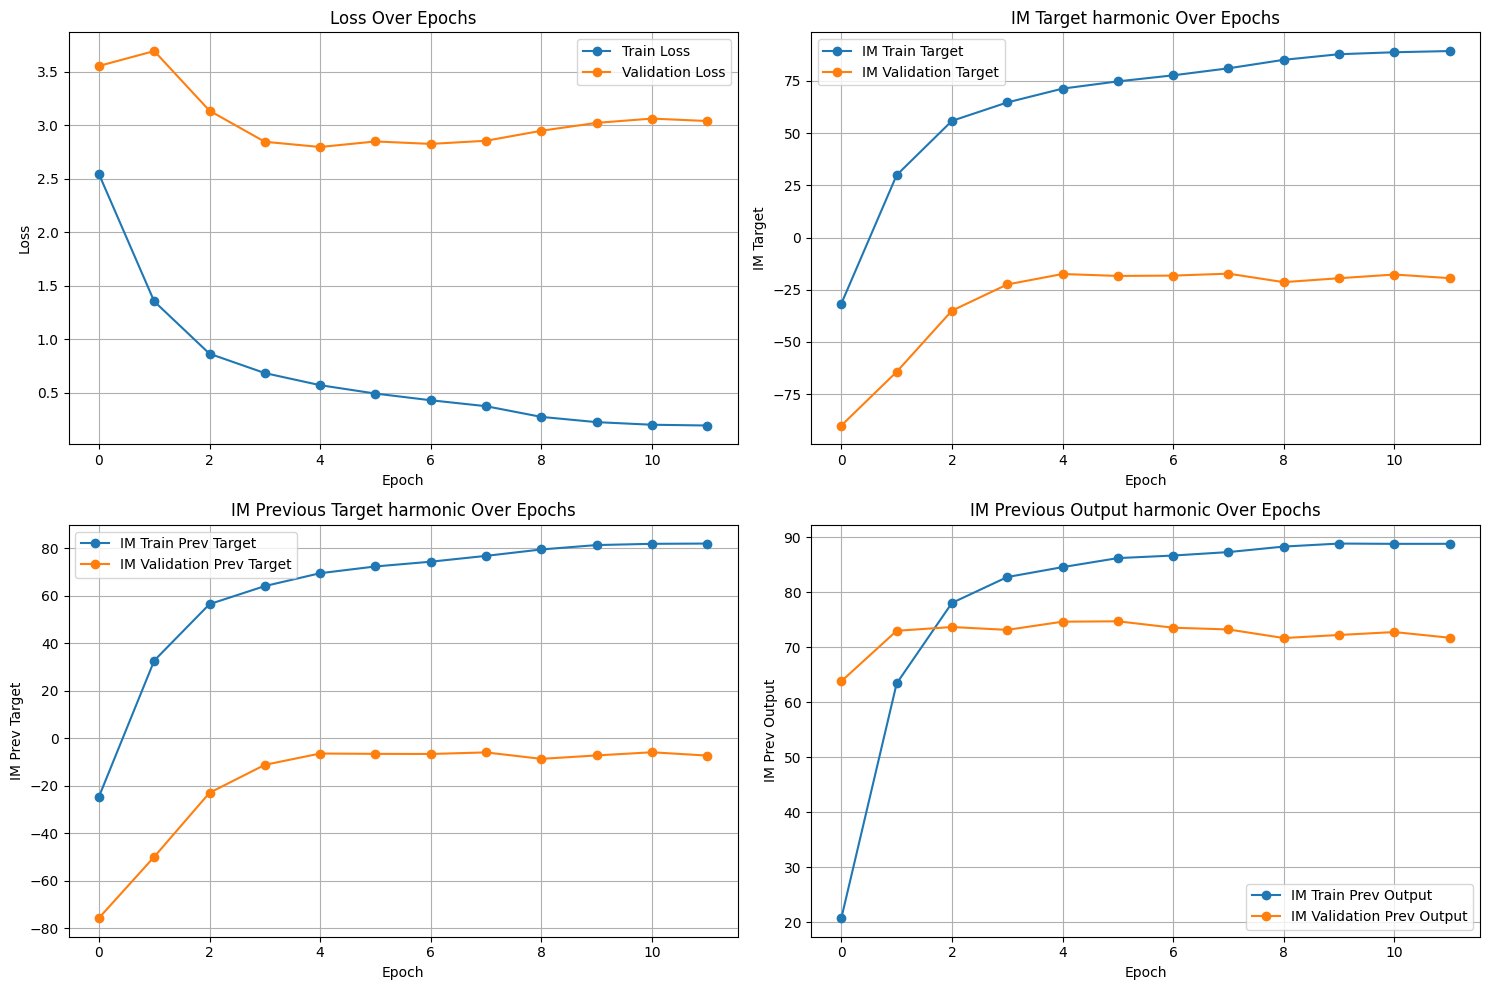

setting up model
finished setting up stem layer
(8, 63, 31)
(8, 63, 31)
(12, 63, 31)
(12, 63, 31)
(16, 63, 31)
(16, 63, 31)
number of layers 6
finished setting up body
head input size (16, 63, 31)
channels = 30, h=61, w=29
finished setting up model
finished setting up parameters
running 0/70
Allocated: 9.06 GB
Reserved: 13.63 GB
Train: Loss: 2.452782392501831 for epoch 0
Eval: Loss: 3.2249600887298584 for epoch 0
running 1/70
Allocated: 12.08 GB
Reserved: 13.63 GB
Train: Loss: 1.0963542461395264 for epoch 1
Eval: Loss: 3.322371006011963 for epoch 1
No improvement in validation loss for 1 epoch(s)
running 2/70
Allocated: 12.08 GB
Reserved: 13.63 GB
Train: Loss: 0.7258465886116028 for epoch 2
Eval: Loss: 2.9105114936828613 for epoch 2
running 3/70
Allocated: 12.08 GB
Reserved: 13.63 GB
Train: Loss: 0.5761207938194275 for epoch 3
Eval: Loss: 2.879526376724243 for epoch 3
running 4/70
Allocated: 12.08 GB
Reserved: 13.63 GB
Train: Loss: 0.4766692519187927 for epoch 4
Eval: Loss: 2.885874271

/content/AudioGenAI/DL_TRAIN_TEST.py:366: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  training_table = training_table.applymap(


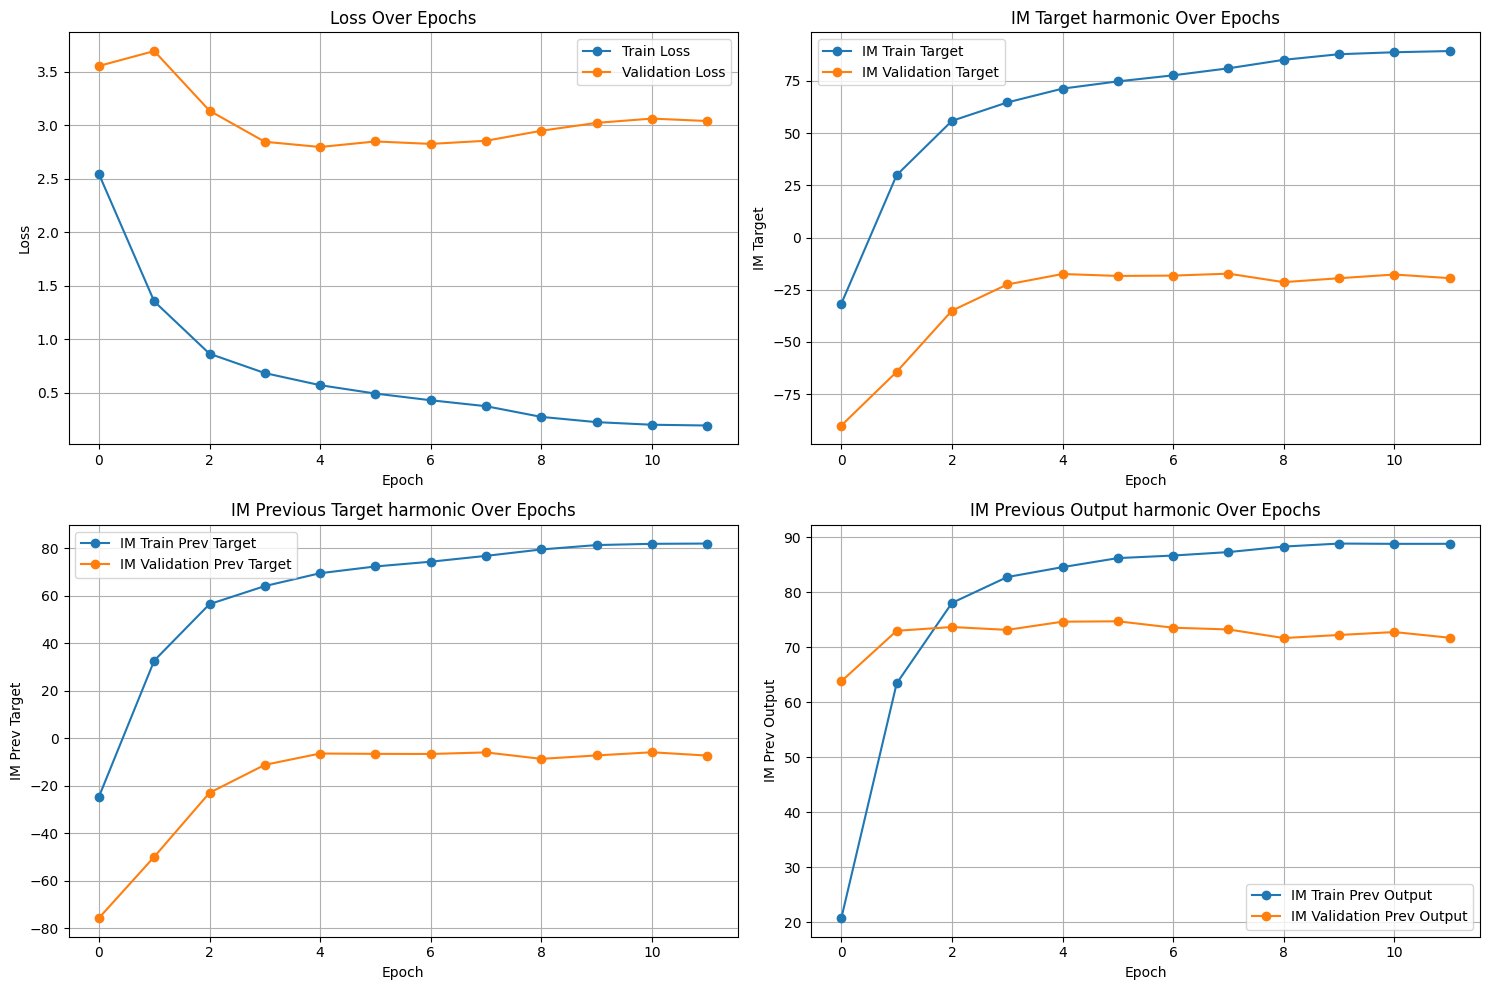

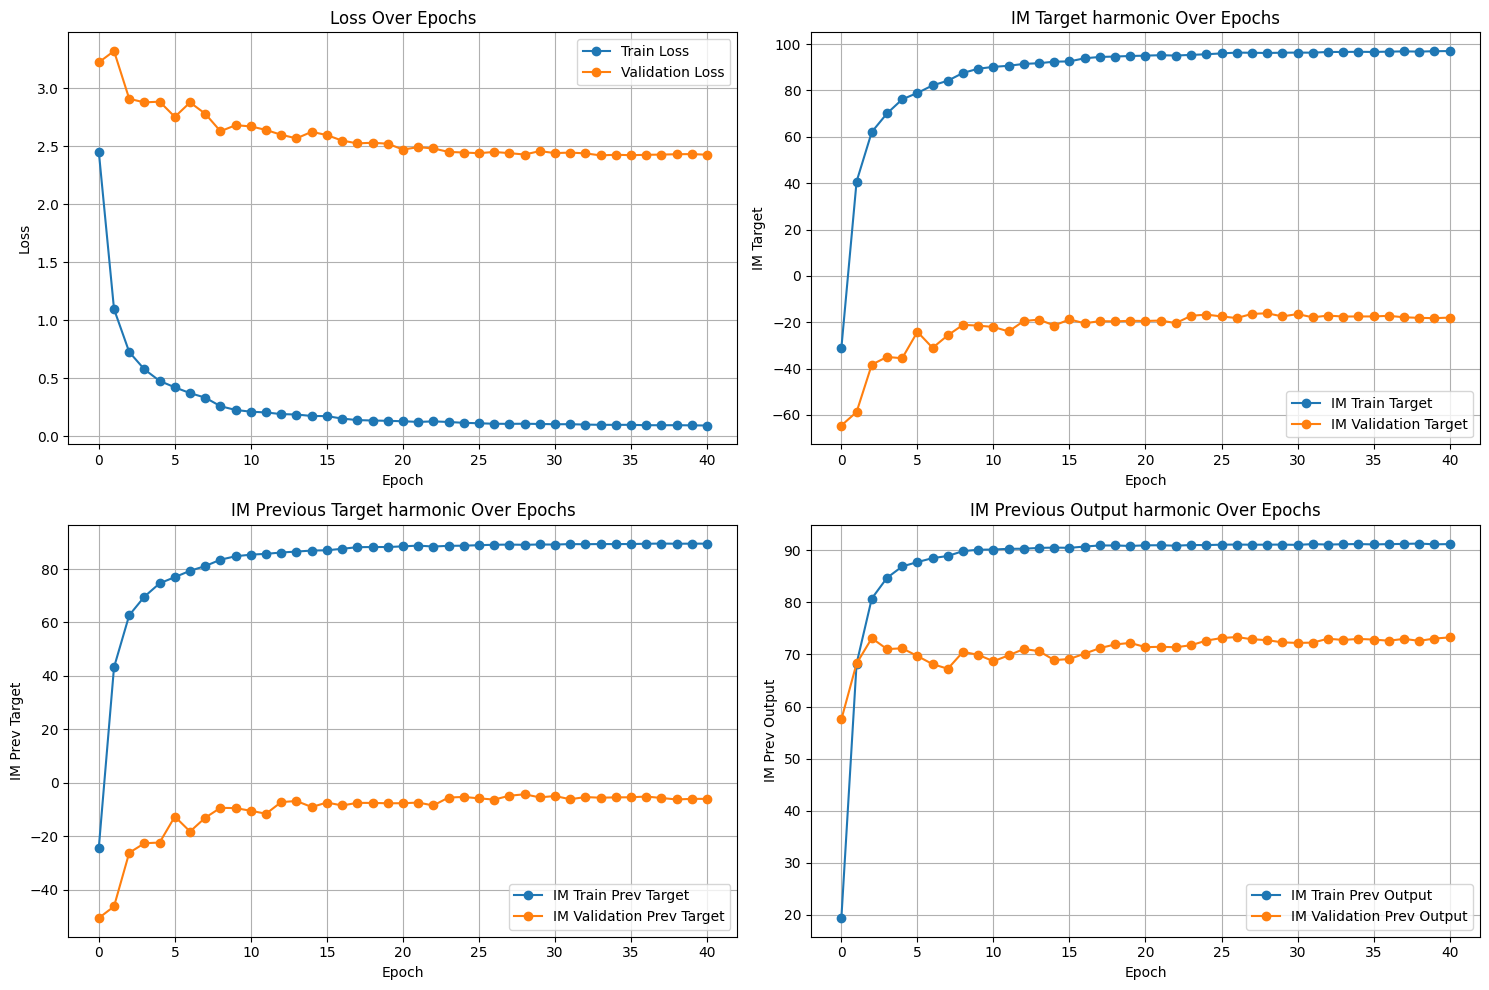

setting up model
finished setting up stem layer
(8, 63, 31)
(8, 63, 31)
(12, 63, 31)
(12, 63, 31)
(16, 63, 31)
(16, 63, 31)
number of layers 6
finished setting up body
head input size (16, 63, 31)
channels = 30, h=61, w=29
finished setting up model
finished setting up parameters
running 0/70
Allocated: 5.04 GB
Reserved: 13.63 GB
Train: Loss: 2.7571051120758057 for epoch 0
Eval: Loss: 3.400129795074463 for epoch 0
running 1/70
Allocated: 8.06 GB
Reserved: 13.63 GB
Train: Loss: 1.3280971050262451 for epoch 1
Eval: Loss: 3.1974544525146484 for epoch 1
running 2/70
Allocated: 8.06 GB
Reserved: 13.63 GB
Train: Loss: 0.9204351305961609 for epoch 2
Eval: Loss: 3.1395623683929443 for epoch 2
running 3/70
Allocated: 8.06 GB
Reserved: 13.63 GB
Train: Loss: 0.7444583177566528 for epoch 3
Eval: Loss: 3.0597288608551025 for epoch 3
running 4/70
Allocated: 8.06 GB
Reserved: 13.63 GB
Train: Loss: 0.6404407620429993 for epoch 4
Eval: Loss: 3.1066651344299316 for epoch 4
No improvement in validation lo

/content/AudioGenAI/DL_TRAIN_TEST.py:366: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  training_table = training_table.applymap(


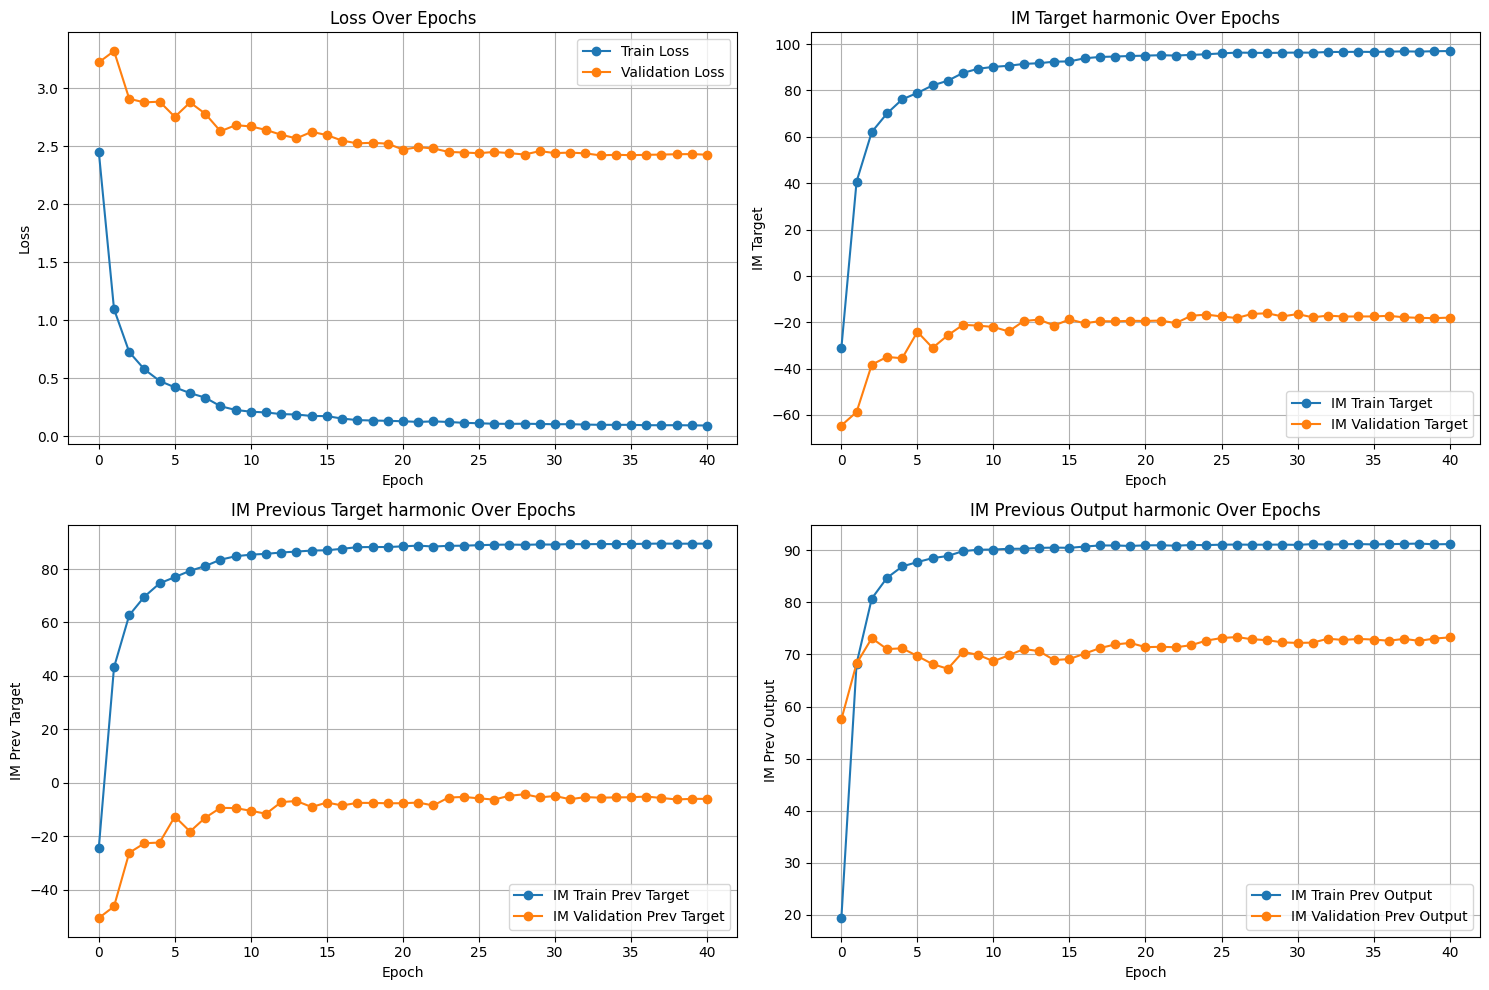

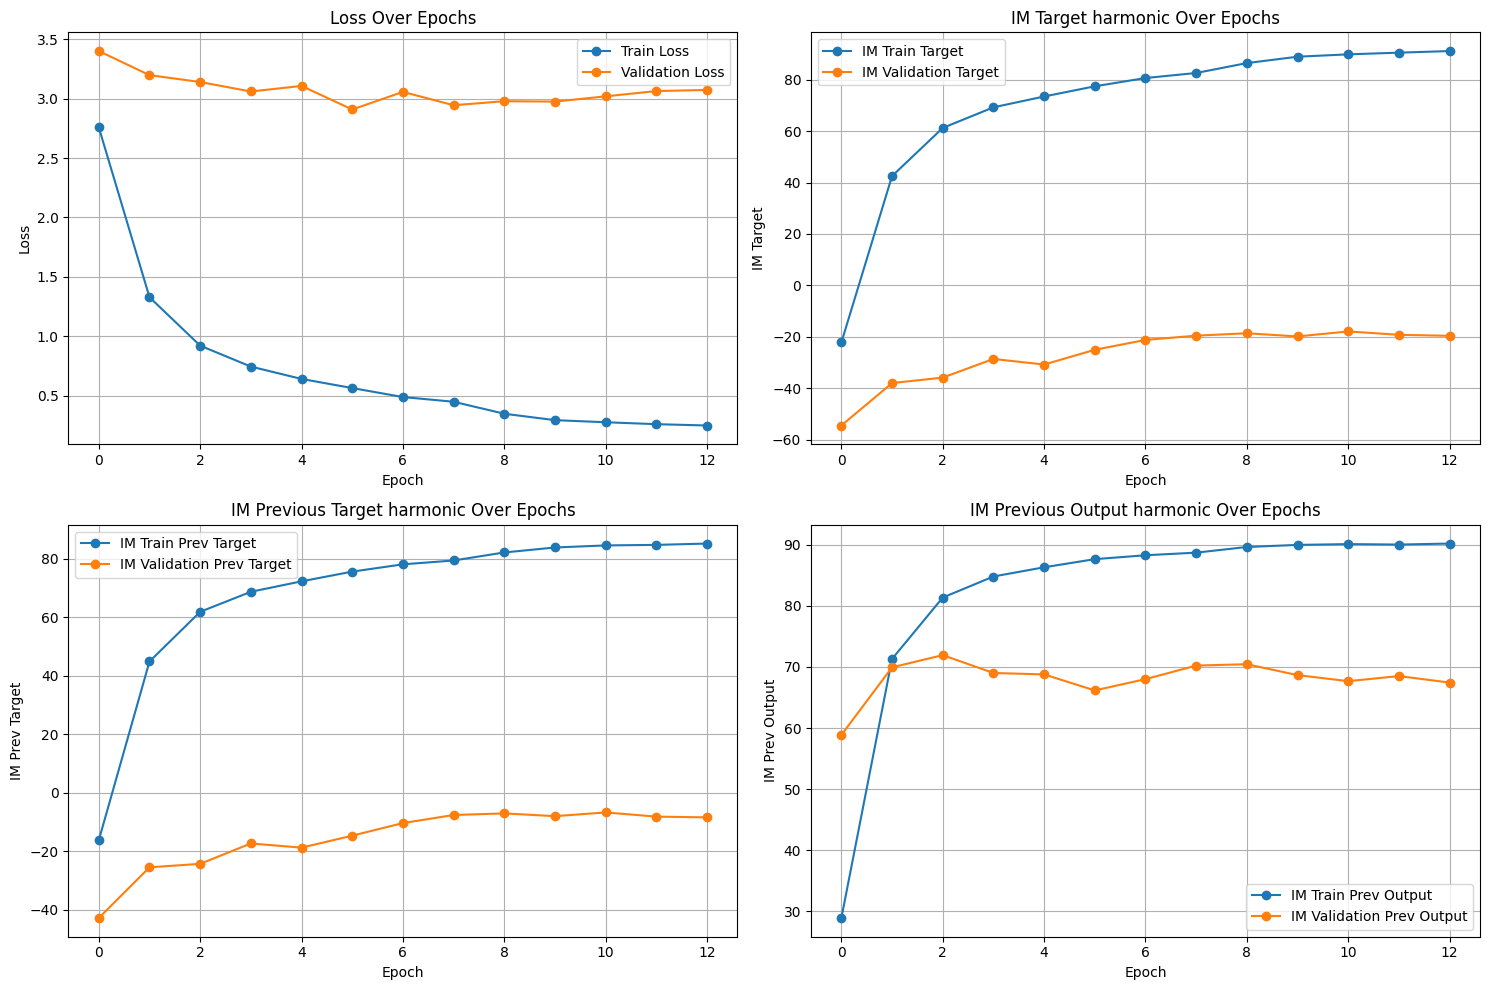

setting up model
finished setting up stem layer
(8, 63, 31)
(8, 63, 31)
(12, 63, 31)
(12, 63, 31)
(16, 63, 31)
(16, 63, 31)
number of layers 6
finished setting up body
head input size (16, 63, 31)
channels = 30, h=61, w=29
finished setting up model
finished setting up parameters
running 0/70
Allocated: 5.04 GB
Reserved: 13.63 GB
Train: Loss: 2.2413718700408936 for epoch 0
Eval: Loss: 2.8074429035186768 for epoch 0
running 1/70
Allocated: 8.06 GB
Reserved: 13.63 GB
Train: Loss: 0.9898779392242432 for epoch 1
Eval: Loss: 2.626744270324707 for epoch 1
running 2/70
Allocated: 8.06 GB
Reserved: 13.63 GB
Train: Loss: 0.625963568687439 for epoch 2
Eval: Loss: 2.4760682582855225 for epoch 2
running 3/70
Allocated: 8.06 GB
Reserved: 13.63 GB
Train: Loss: 0.4780983328819275 for epoch 3
Eval: Loss: 2.3735978603363037 for epoch 3
running 4/70
Allocated: 8.06 GB
Reserved: 13.63 GB
Train: Loss: 0.40211135149002075 for epoch 4
Eval: Loss: 2.1980018615722656 for epoch 4
running 5/70
Allocated: 8.06 GB

/content/AudioGenAI/DL_TRAIN_TEST.py:366: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  training_table = training_table.applymap(


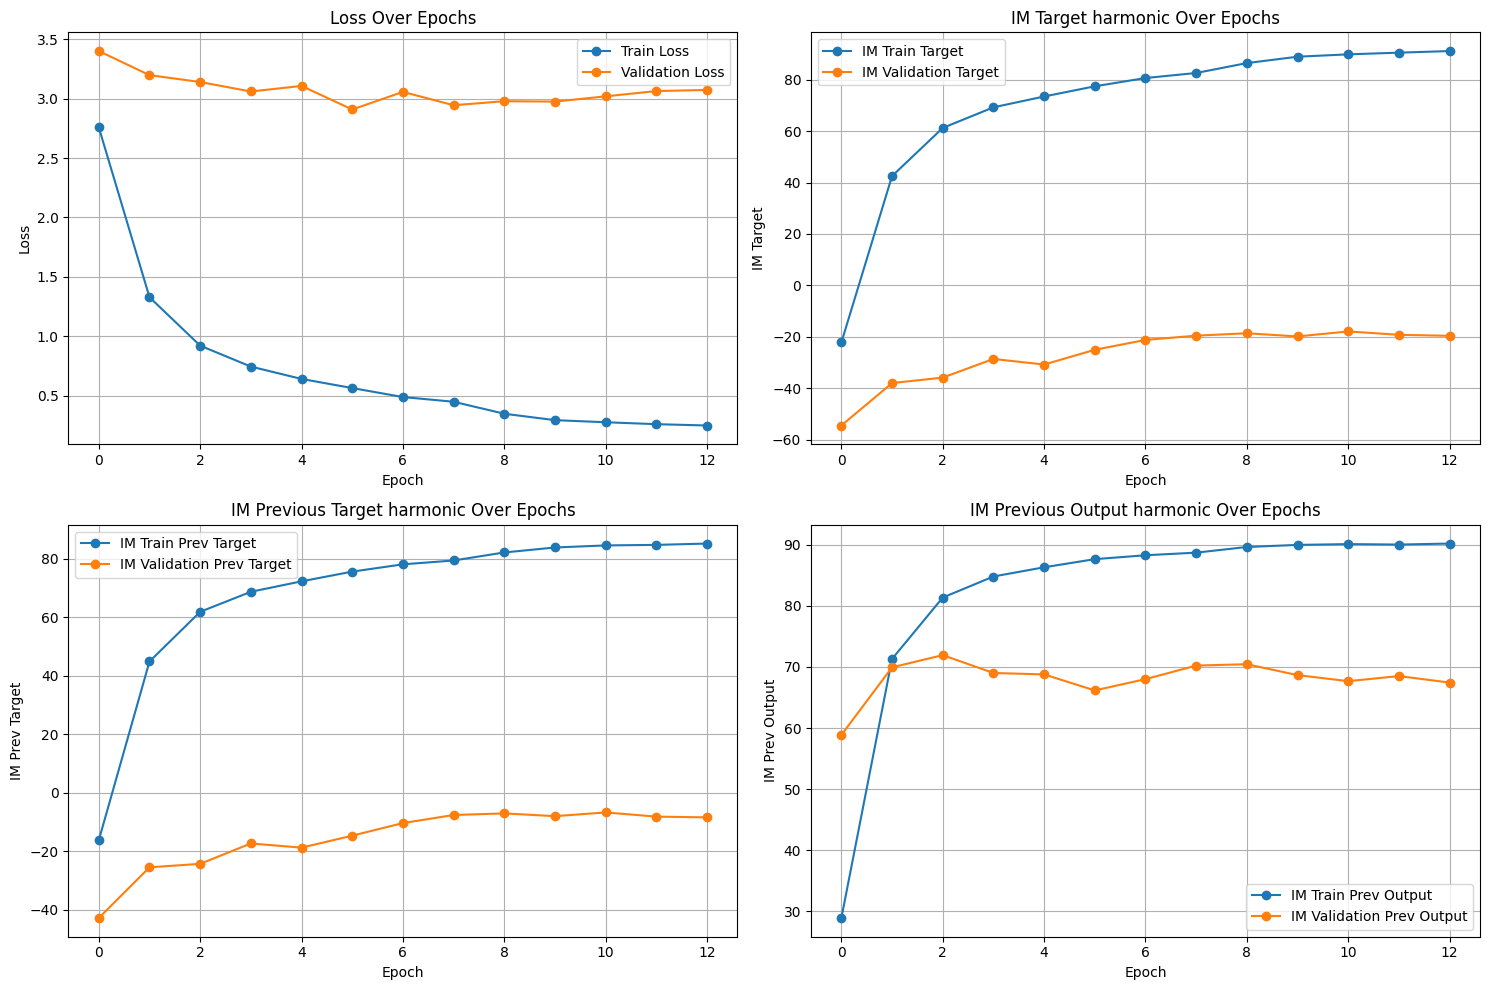

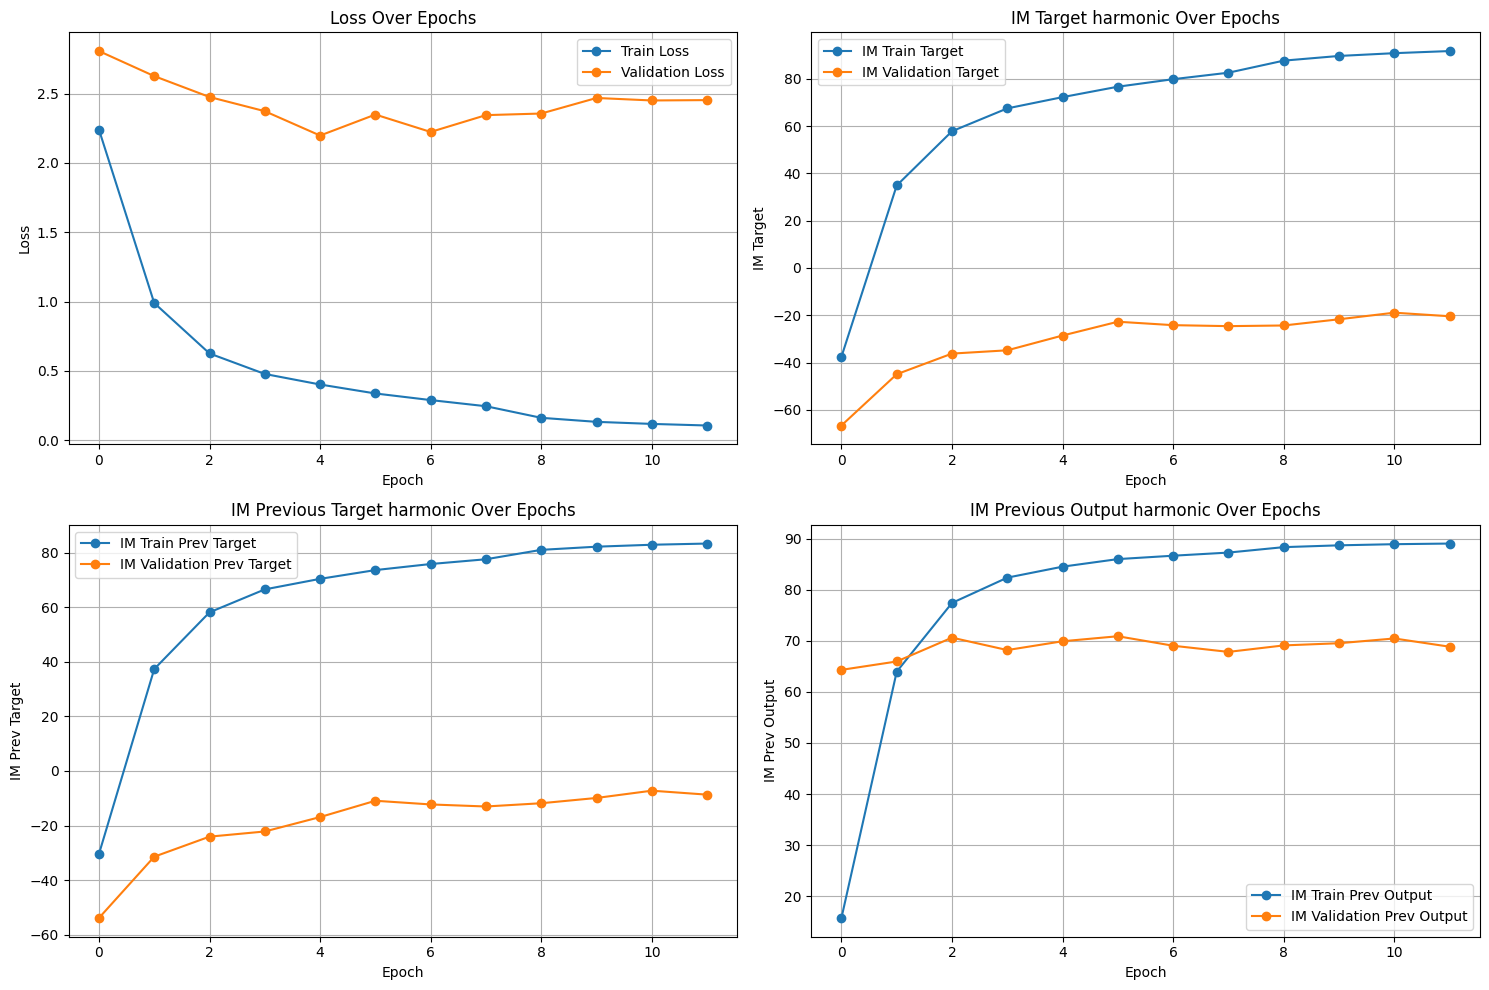

finished setting up parameters
running 0/70
Allocated: 4.10 GB
Reserved: 13.64 GB
Train: Loss: 1.2711429595947266 for epoch 0
Eval: Loss: 1.2174184322357178 for epoch 0
running 1/70
Allocated: 4.24 GB
Reserved: 13.73 GB
Train: Loss: 0.4800608456134796 for epoch 1
Eval: Loss: 1.4367939233779907 for epoch 1
No improvement in validation loss for 1 epoch(s)
running 2/70
Allocated: 4.24 GB
Reserved: 13.73 GB
Train: Loss: 0.4059605002403259 for epoch 2
Eval: Loss: 1.2174307107925415 for epoch 2
No improvement in validation loss for 2 epoch(s)
running 3/70
Allocated: 4.24 GB
Reserved: 13.73 GB
Train: Loss: 0.36088642477989197 for epoch 3
Eval: Loss: 1.0738122463226318 for epoch 3
running 4/70
Allocated: 4.24 GB
Reserved: 13.73 GB
Train: Loss: 0.3260454535484314 for epoch 4
Eval: Loss: 1.386625051498413 for epoch 4
No improvement in validation loss for 1 epoch(s)
running 5/70
Allocated: 4.24 GB
Reserved: 13.73 GB
Train: Loss: 0.3095054626464844 for epoch 5
Eval: Loss: 1.468870997428894 for epo

/content/AudioGenAI/DL_TRAIN_TEST.py:366: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  training_table = training_table.applymap(


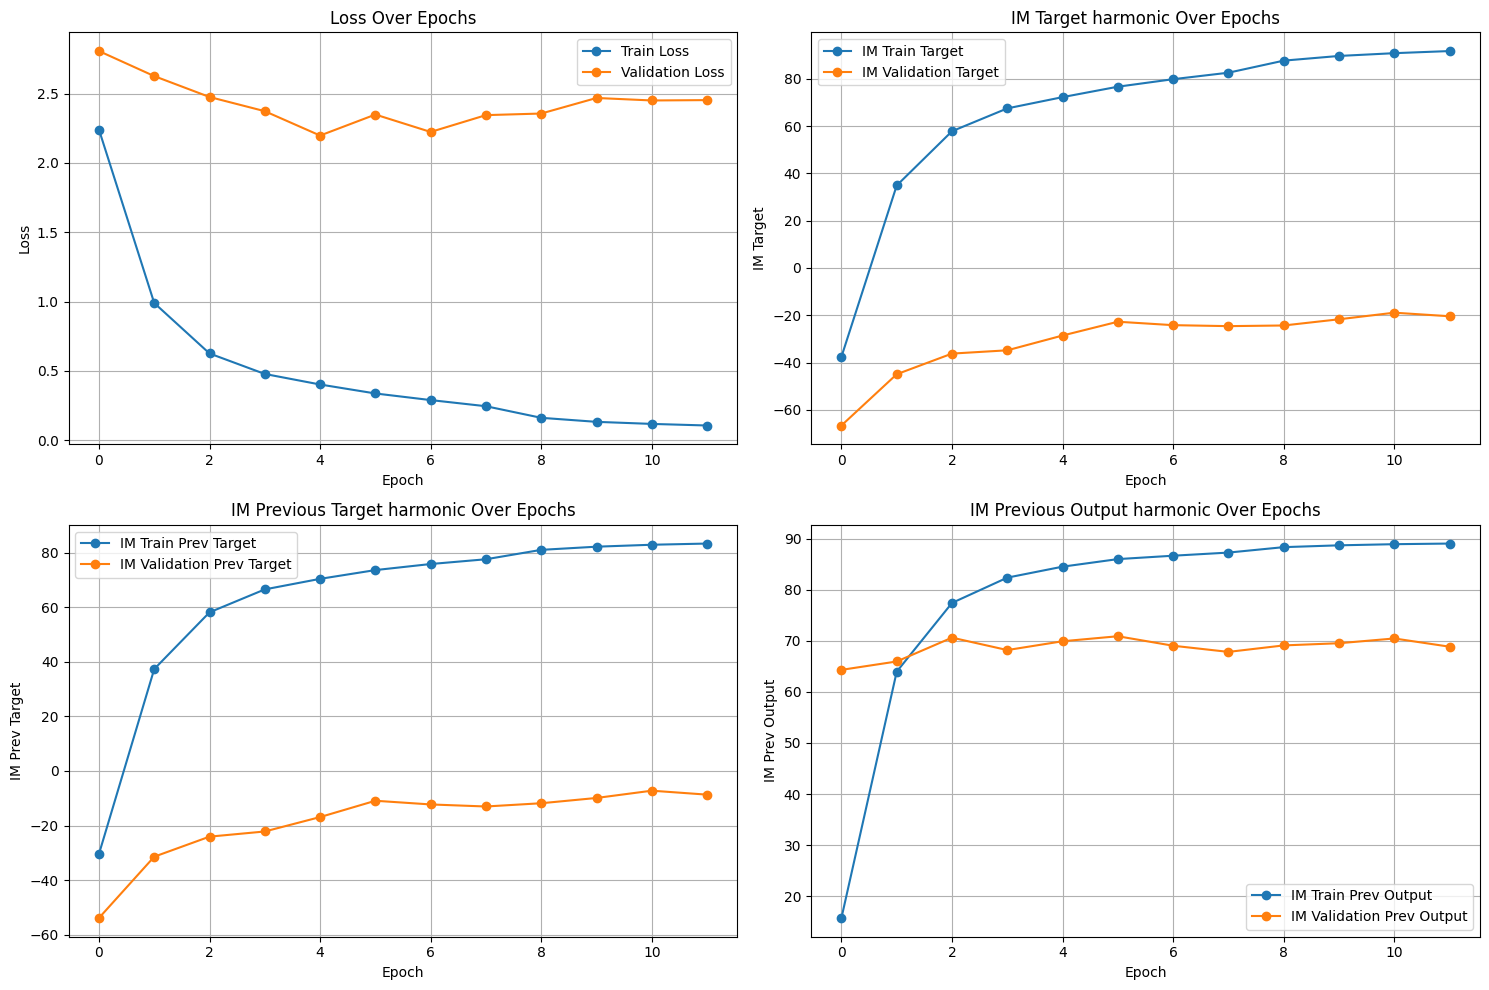

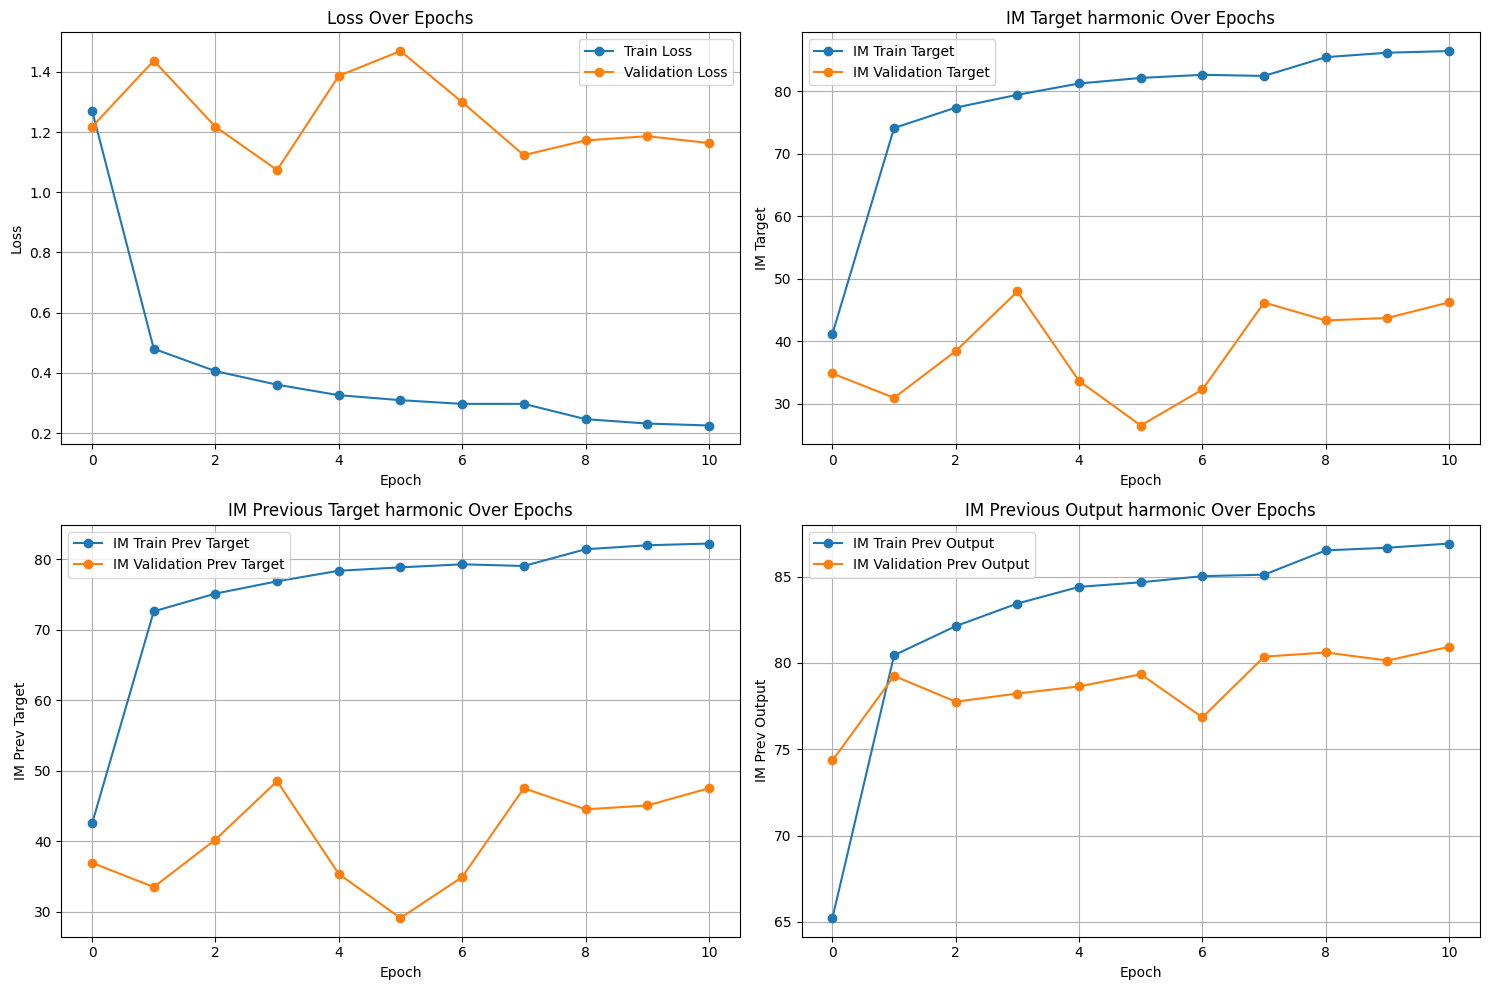

finished setting up parameters
running 0/70
Allocated: 4.19 GB
Reserved: 13.73 GB
Train: Loss: 1.3020131587982178 for epoch 0
Eval: Loss: 1.5581632852554321 for epoch 0
running 1/70
Allocated: 4.25 GB
Reserved: 13.77 GB
Train: Loss: 0.4918806254863739 for epoch 1
Eval: Loss: 1.3007935285568237 for epoch 1
running 2/70
Allocated: 4.25 GB
Reserved: 13.77 GB
Train: Loss: 0.4158259630203247 for epoch 2
Eval: Loss: 1.20219886302948 for epoch 2
running 3/70
Allocated: 4.25 GB
Reserved: 13.77 GB
Train: Loss: 0.3721315860748291 for epoch 3
Eval: Loss: 1.1062192916870117 for epoch 3
running 4/70
Allocated: 4.25 GB
Reserved: 13.77 GB
Train: Loss: 0.34876638650894165 for epoch 4
Eval: Loss: 1.2477943897247314 for epoch 4
No improvement in validation loss for 1 epoch(s)
running 5/70
Allocated: 4.25 GB
Reserved: 13.77 GB
Train: Loss: 0.3318779468536377 for epoch 5
Eval: Loss: 1.4715567827224731 for epoch 5
No improvement in validation loss for 2 epoch(s)
running 6/70
Allocated: 4.25 GB
Reserved: 13

/content/AudioGenAI/DL_TRAIN_TEST.py:366: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  training_table = training_table.applymap(


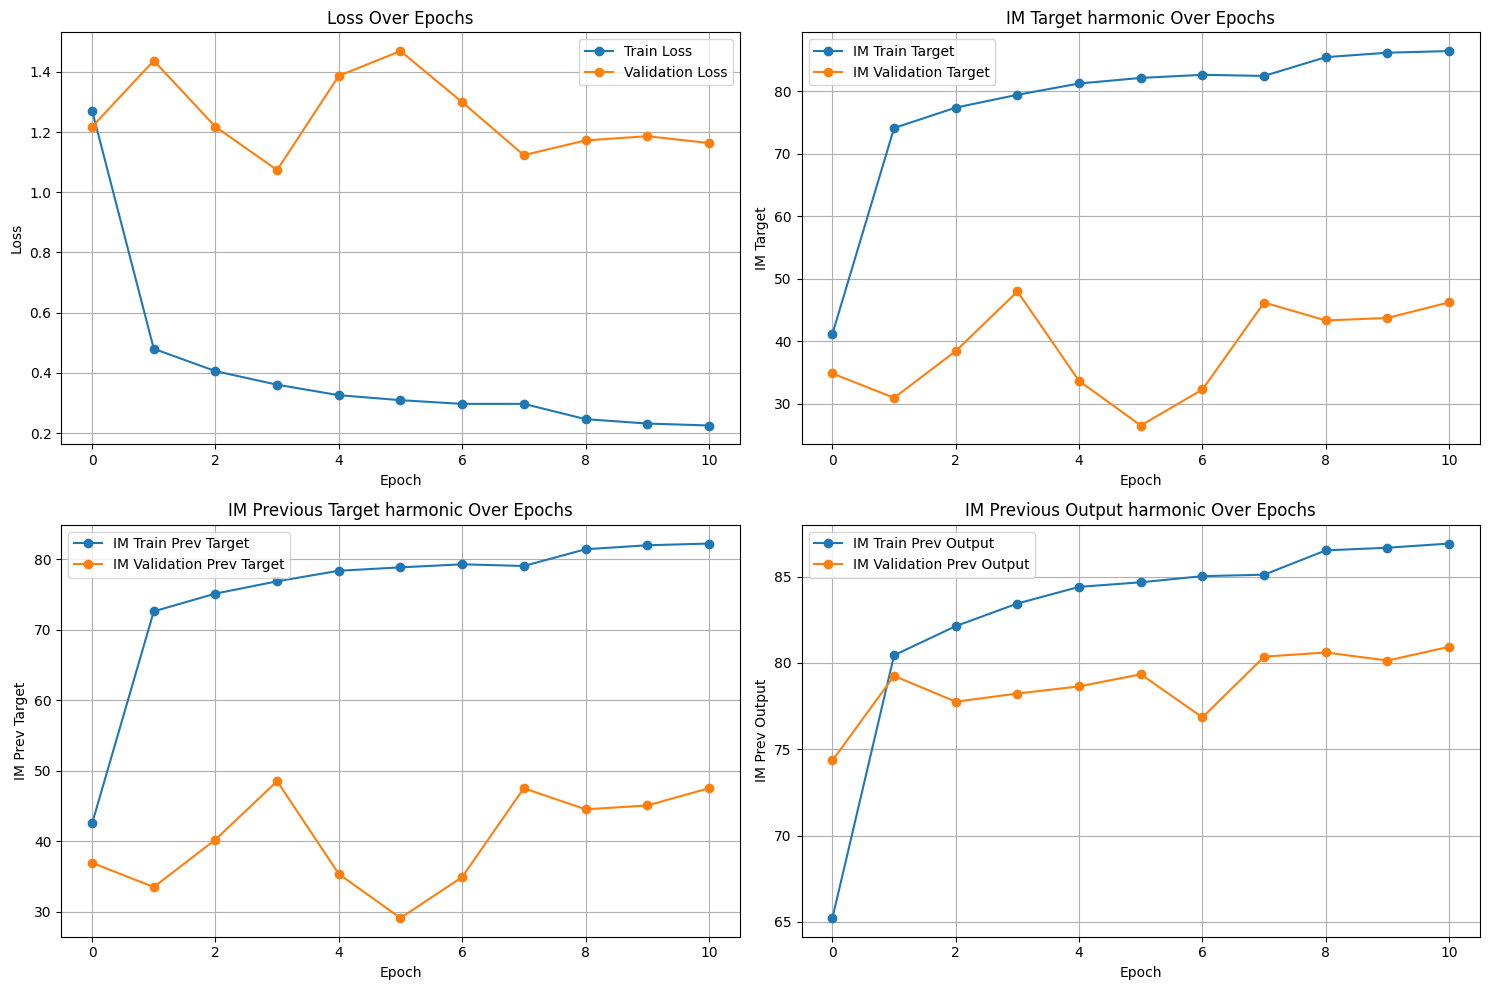

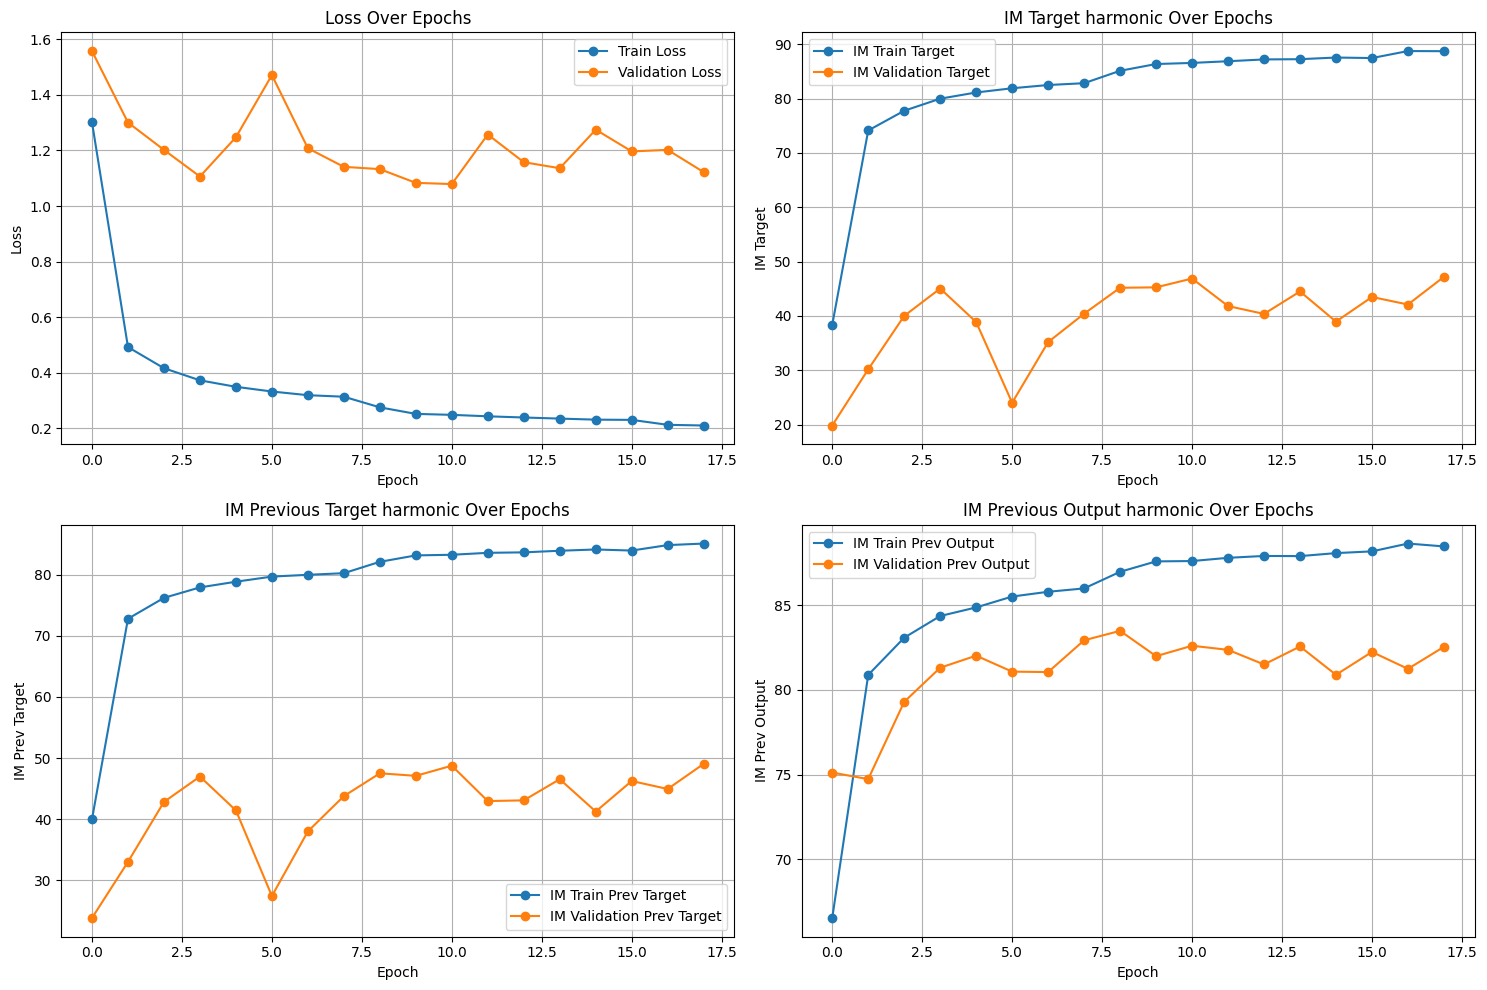

finished setting up parameters
running 0/70
Allocated: 4.20 GB
Reserved: 13.77 GB
Train: Loss: 1.4902143478393555 for epoch 0
Eval: Loss: 1.9329475164413452 for epoch 0
running 1/70
Allocated: 4.25 GB
Reserved: 13.77 GB
Train: Loss: 0.6226925849914551 for epoch 1
Eval: Loss: 1.4773473739624023 for epoch 1
running 2/70
Allocated: 4.25 GB
Reserved: 13.77 GB
Train: Loss: 0.5350891351699829 for epoch 2
Eval: Loss: 1.3201154470443726 for epoch 2
running 3/70
Allocated: 4.25 GB
Reserved: 13.77 GB
Train: Loss: 0.48200175166130066 for epoch 3
Eval: Loss: 1.5739237070083618 for epoch 3
No improvement in validation loss for 1 epoch(s)
running 4/70
Allocated: 4.25 GB
Reserved: 13.77 GB
Train: Loss: 0.4507890045642853 for epoch 4
Eval: Loss: 1.495125651359558 for epoch 4
No improvement in validation loss for 2 epoch(s)
running 5/70
Allocated: 4.25 GB
Reserved: 13.77 GB
Train: Loss: 0.4228895306587219 for epoch 5
Eval: Loss: 1.8289899826049805 for epoch 5
No improvement in validation loss for 3 epo

/content/AudioGenAI/DL_TRAIN_TEST.py:366: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  training_table = training_table.applymap(


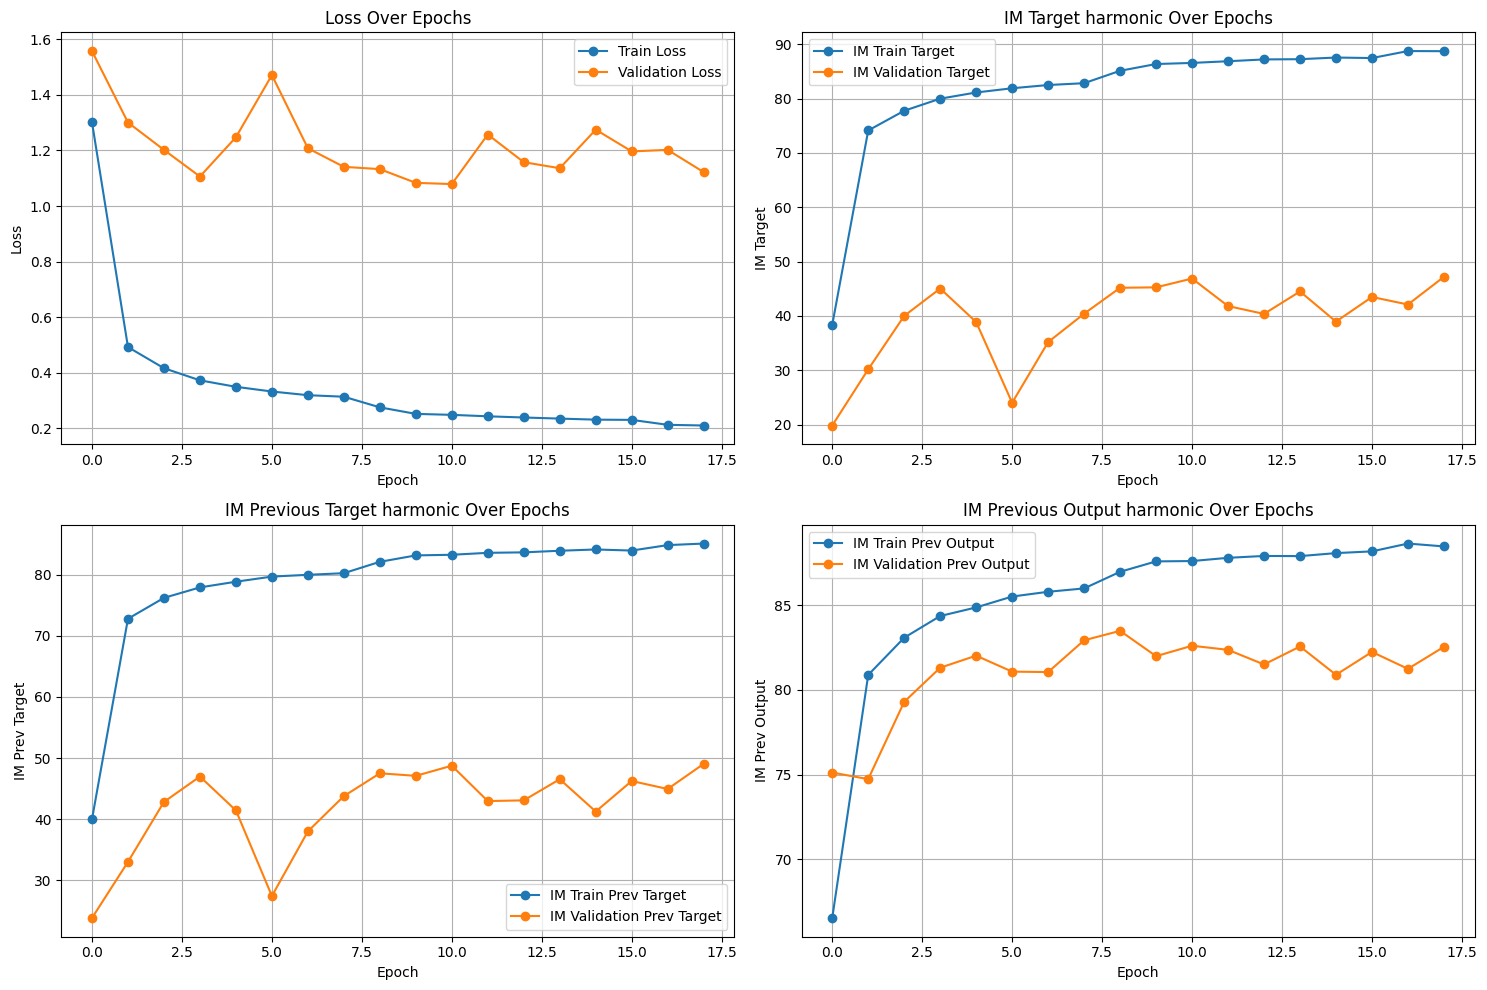

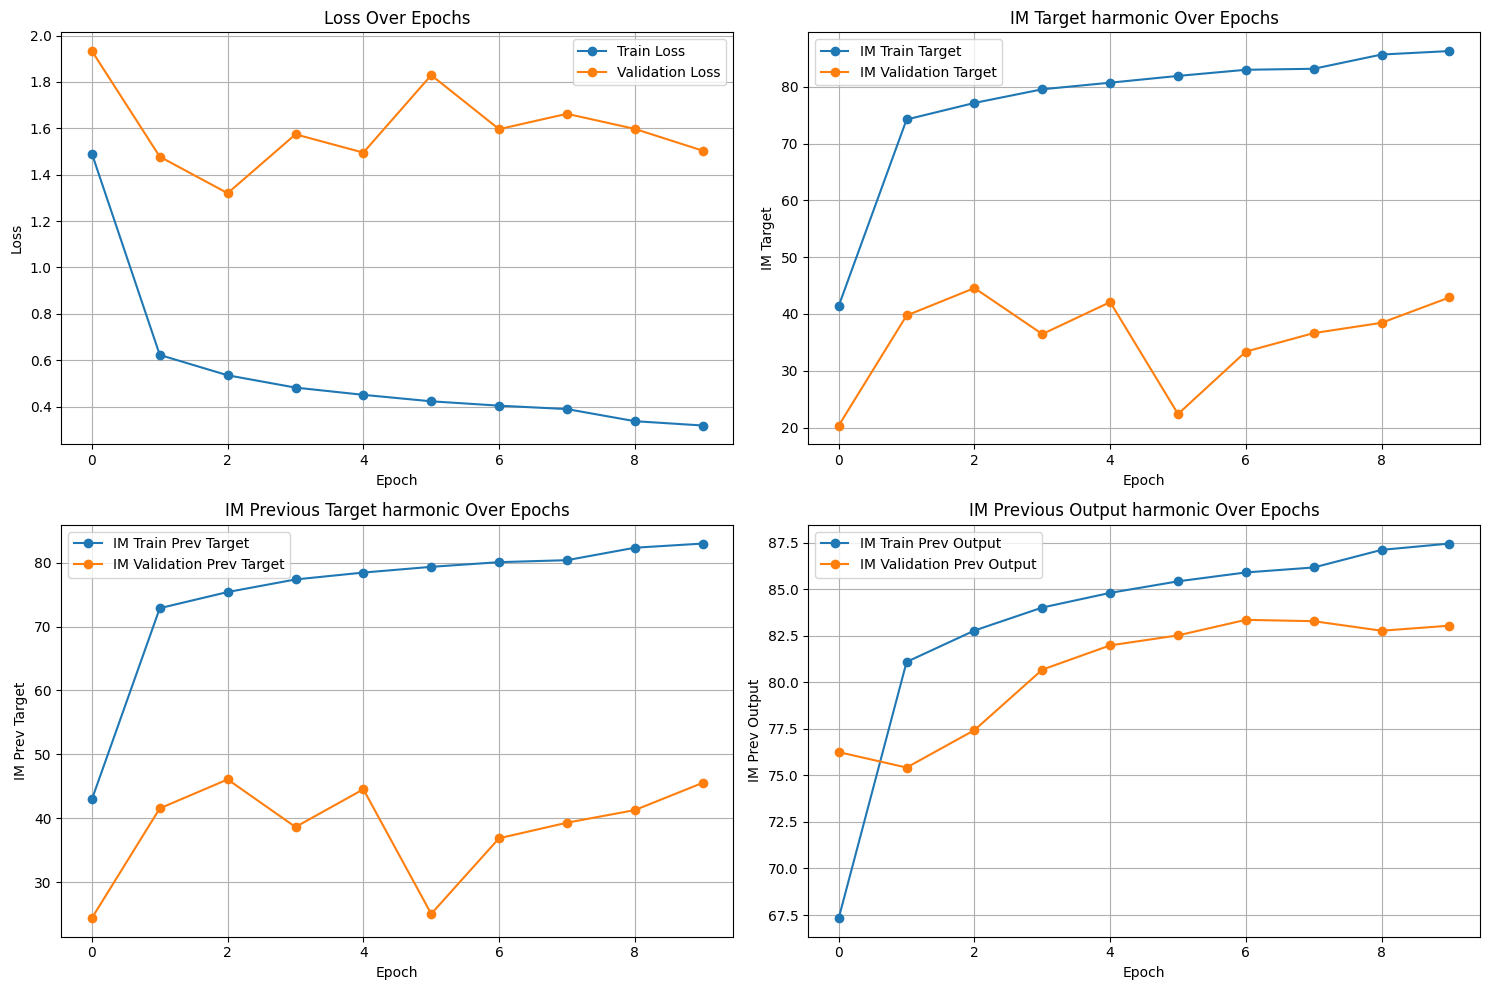

finished setting up parameters
running 0/70
Allocated: 4.20 GB
Reserved: 13.77 GB
Train: Loss: 1.1042381525039673 for epoch 0
Eval: Loss: 1.1856023073196411 for epoch 0
running 1/70
Allocated: 4.25 GB
Reserved: 13.77 GB
Train: Loss: 0.35091274976730347 for epoch 1
Eval: Loss: 0.958222508430481 for epoch 1
running 2/70
Allocated: 4.25 GB
Reserved: 13.77 GB
Train: Loss: 0.28945761919021606 for epoch 2
Eval: Loss: 1.1430848836898804 for epoch 2
No improvement in validation loss for 1 epoch(s)
running 3/70
Allocated: 4.25 GB
Reserved: 13.77 GB
Train: Loss: 0.2636176645755768 for epoch 3
Eval: Loss: 1.1065126657485962 for epoch 3
No improvement in validation loss for 2 epoch(s)
running 4/70
Allocated: 4.25 GB
Reserved: 13.77 GB
Train: Loss: 0.2336575984954834 for epoch 4
Eval: Loss: 1.0574250221252441 for epoch 4
No improvement in validation loss for 3 epoch(s)
running 5/70
Allocated: 4.25 GB
Reserved: 13.77 GB
Train: Loss: 0.22255077958106995 for epoch 5
Eval: Loss: 0.9913784265518188 for 

/content/AudioGenAI/DL_TRAIN_TEST.py:366: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  training_table = training_table.applymap(


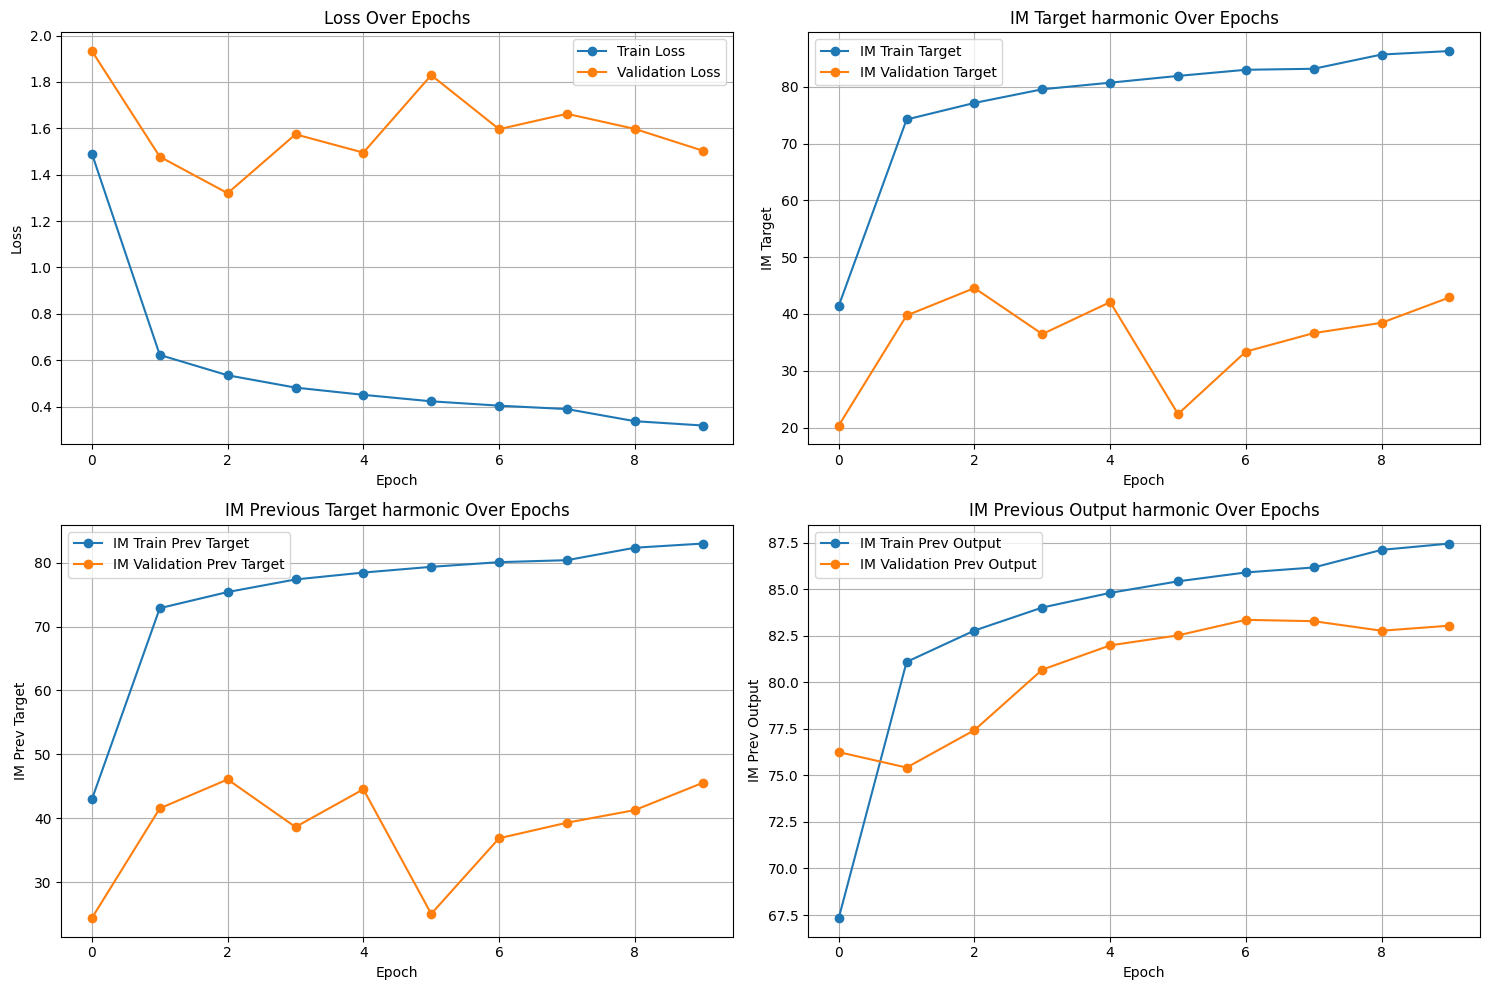

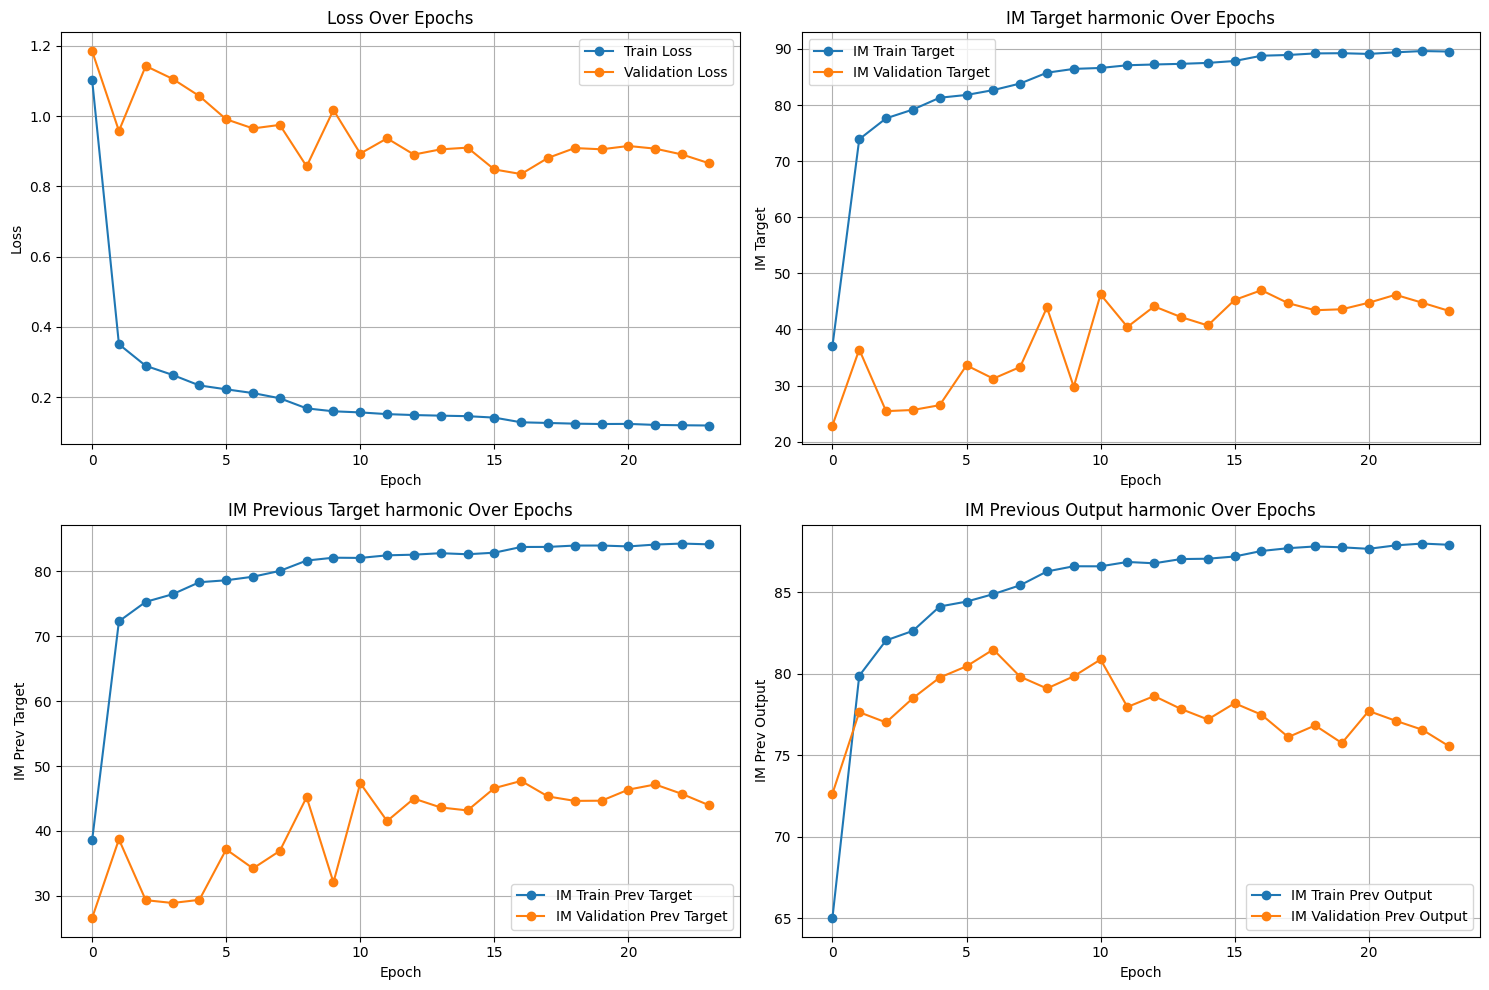

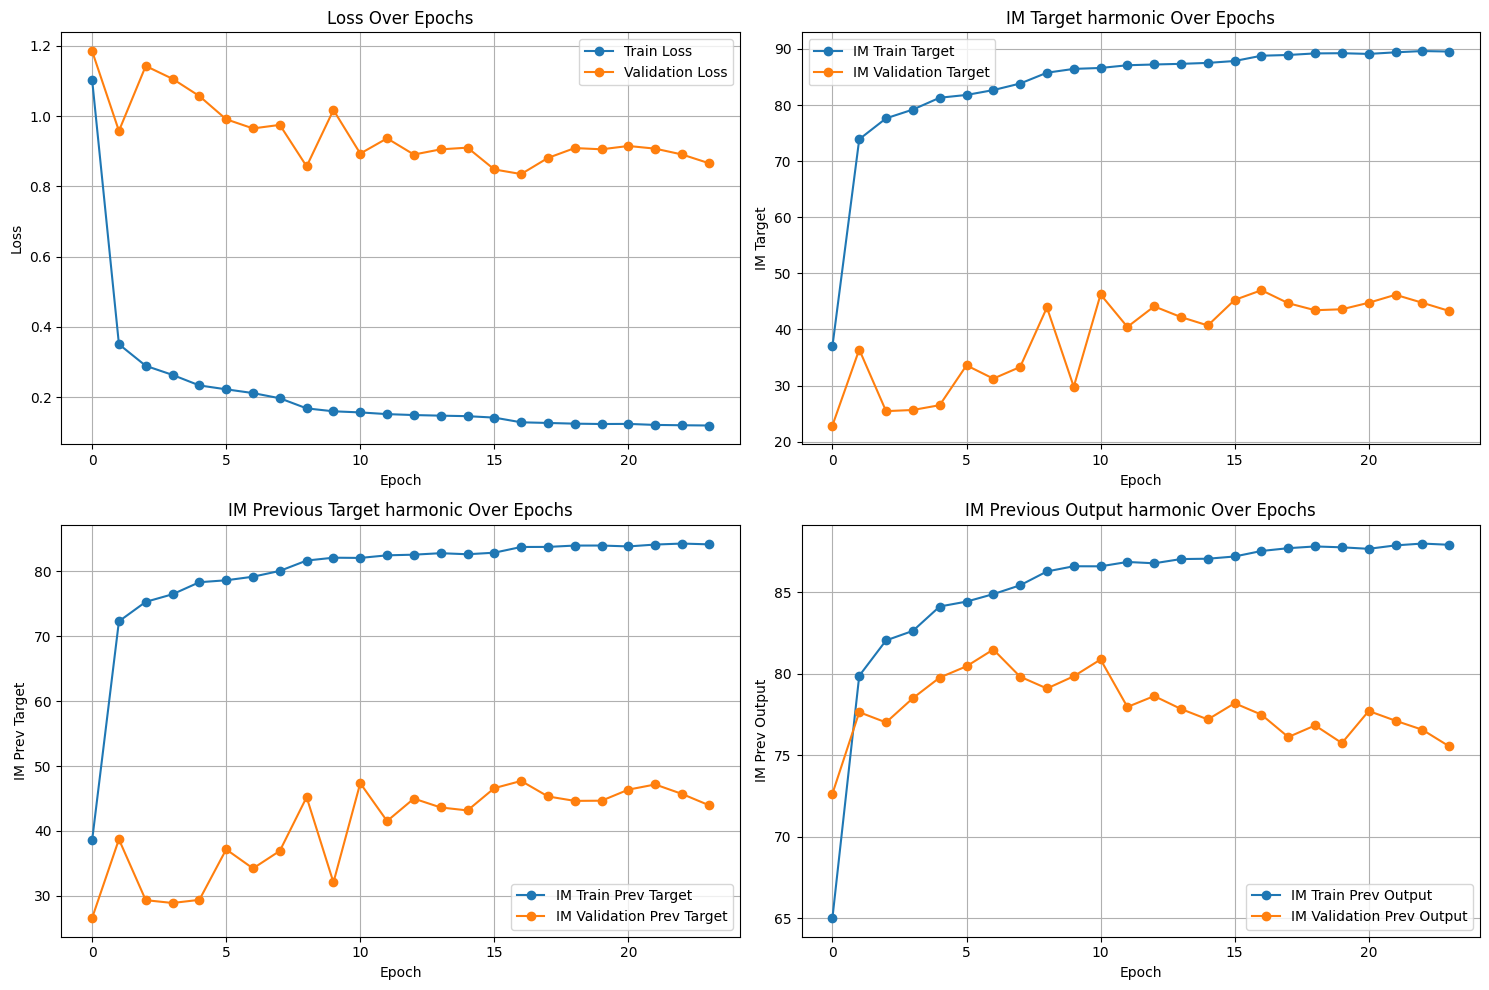

In [12]:
for t in test_type:
  for i, tests in enumerate(test_names):
    trainer = train_and_test.Train(model_type=t, path=r"{0}/{1}/{2}{3}".format(project_path, folder_name, t,tests), validation_set =validation_ds, training_set=train_ds, device = device )
    if(t ==train_and_test.MODEL_TYPE.CNN):
      trainer.set_model(
          seq_len=64,
          dropout=0.5,
          dropout_depth=0.2
      )
    if(t ==train_and_test.MODEL_TYPE.TRANSFORMER):
      trainer.set_model(
        seq_len=64,
        dropout=0.5,
        hidden_dim = 512,
        num_encoder_layers = 4,
        num_decoder_layers=2
        )
    trainer.set_training_params(
        lr_step= 8,
        lr_start= 5e-4,
        lr_mul=0.5,
        batch_size=32,
        patience = 7,
        with_eval_set =True
    )
    trainer.set_loss_function(weights_target=params_test[i][0], weights_before=params_test[i][1])
    trainer.train(epoch_size=70)
    trainer.save_model_weights()
    trainer.save_training()

Compare all the training results in one plot.

/tmp/ipython-input-15-2924875788.py:22: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(labels))
/tmp/ipython-input-15-2924875788.py:28: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  table = table.applymap(lambda x: x.detach().cpu().item() if torch.is_tensor(x) else x)
/tmp/ipython-input-15-2924875788.py:28: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  table = table.applymap(lambda x: x.detach().cpu().item() if torch.is_tensor(x) else x)
/tmp/ipython-input-15-2924875788.py:28: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  table = table.applymap(lambda x: x.detach().cpu().item() if torch.is_tensor(x) else x)
/tmp/ipython-input-15-2924875788.py:28: FutureWarning: D

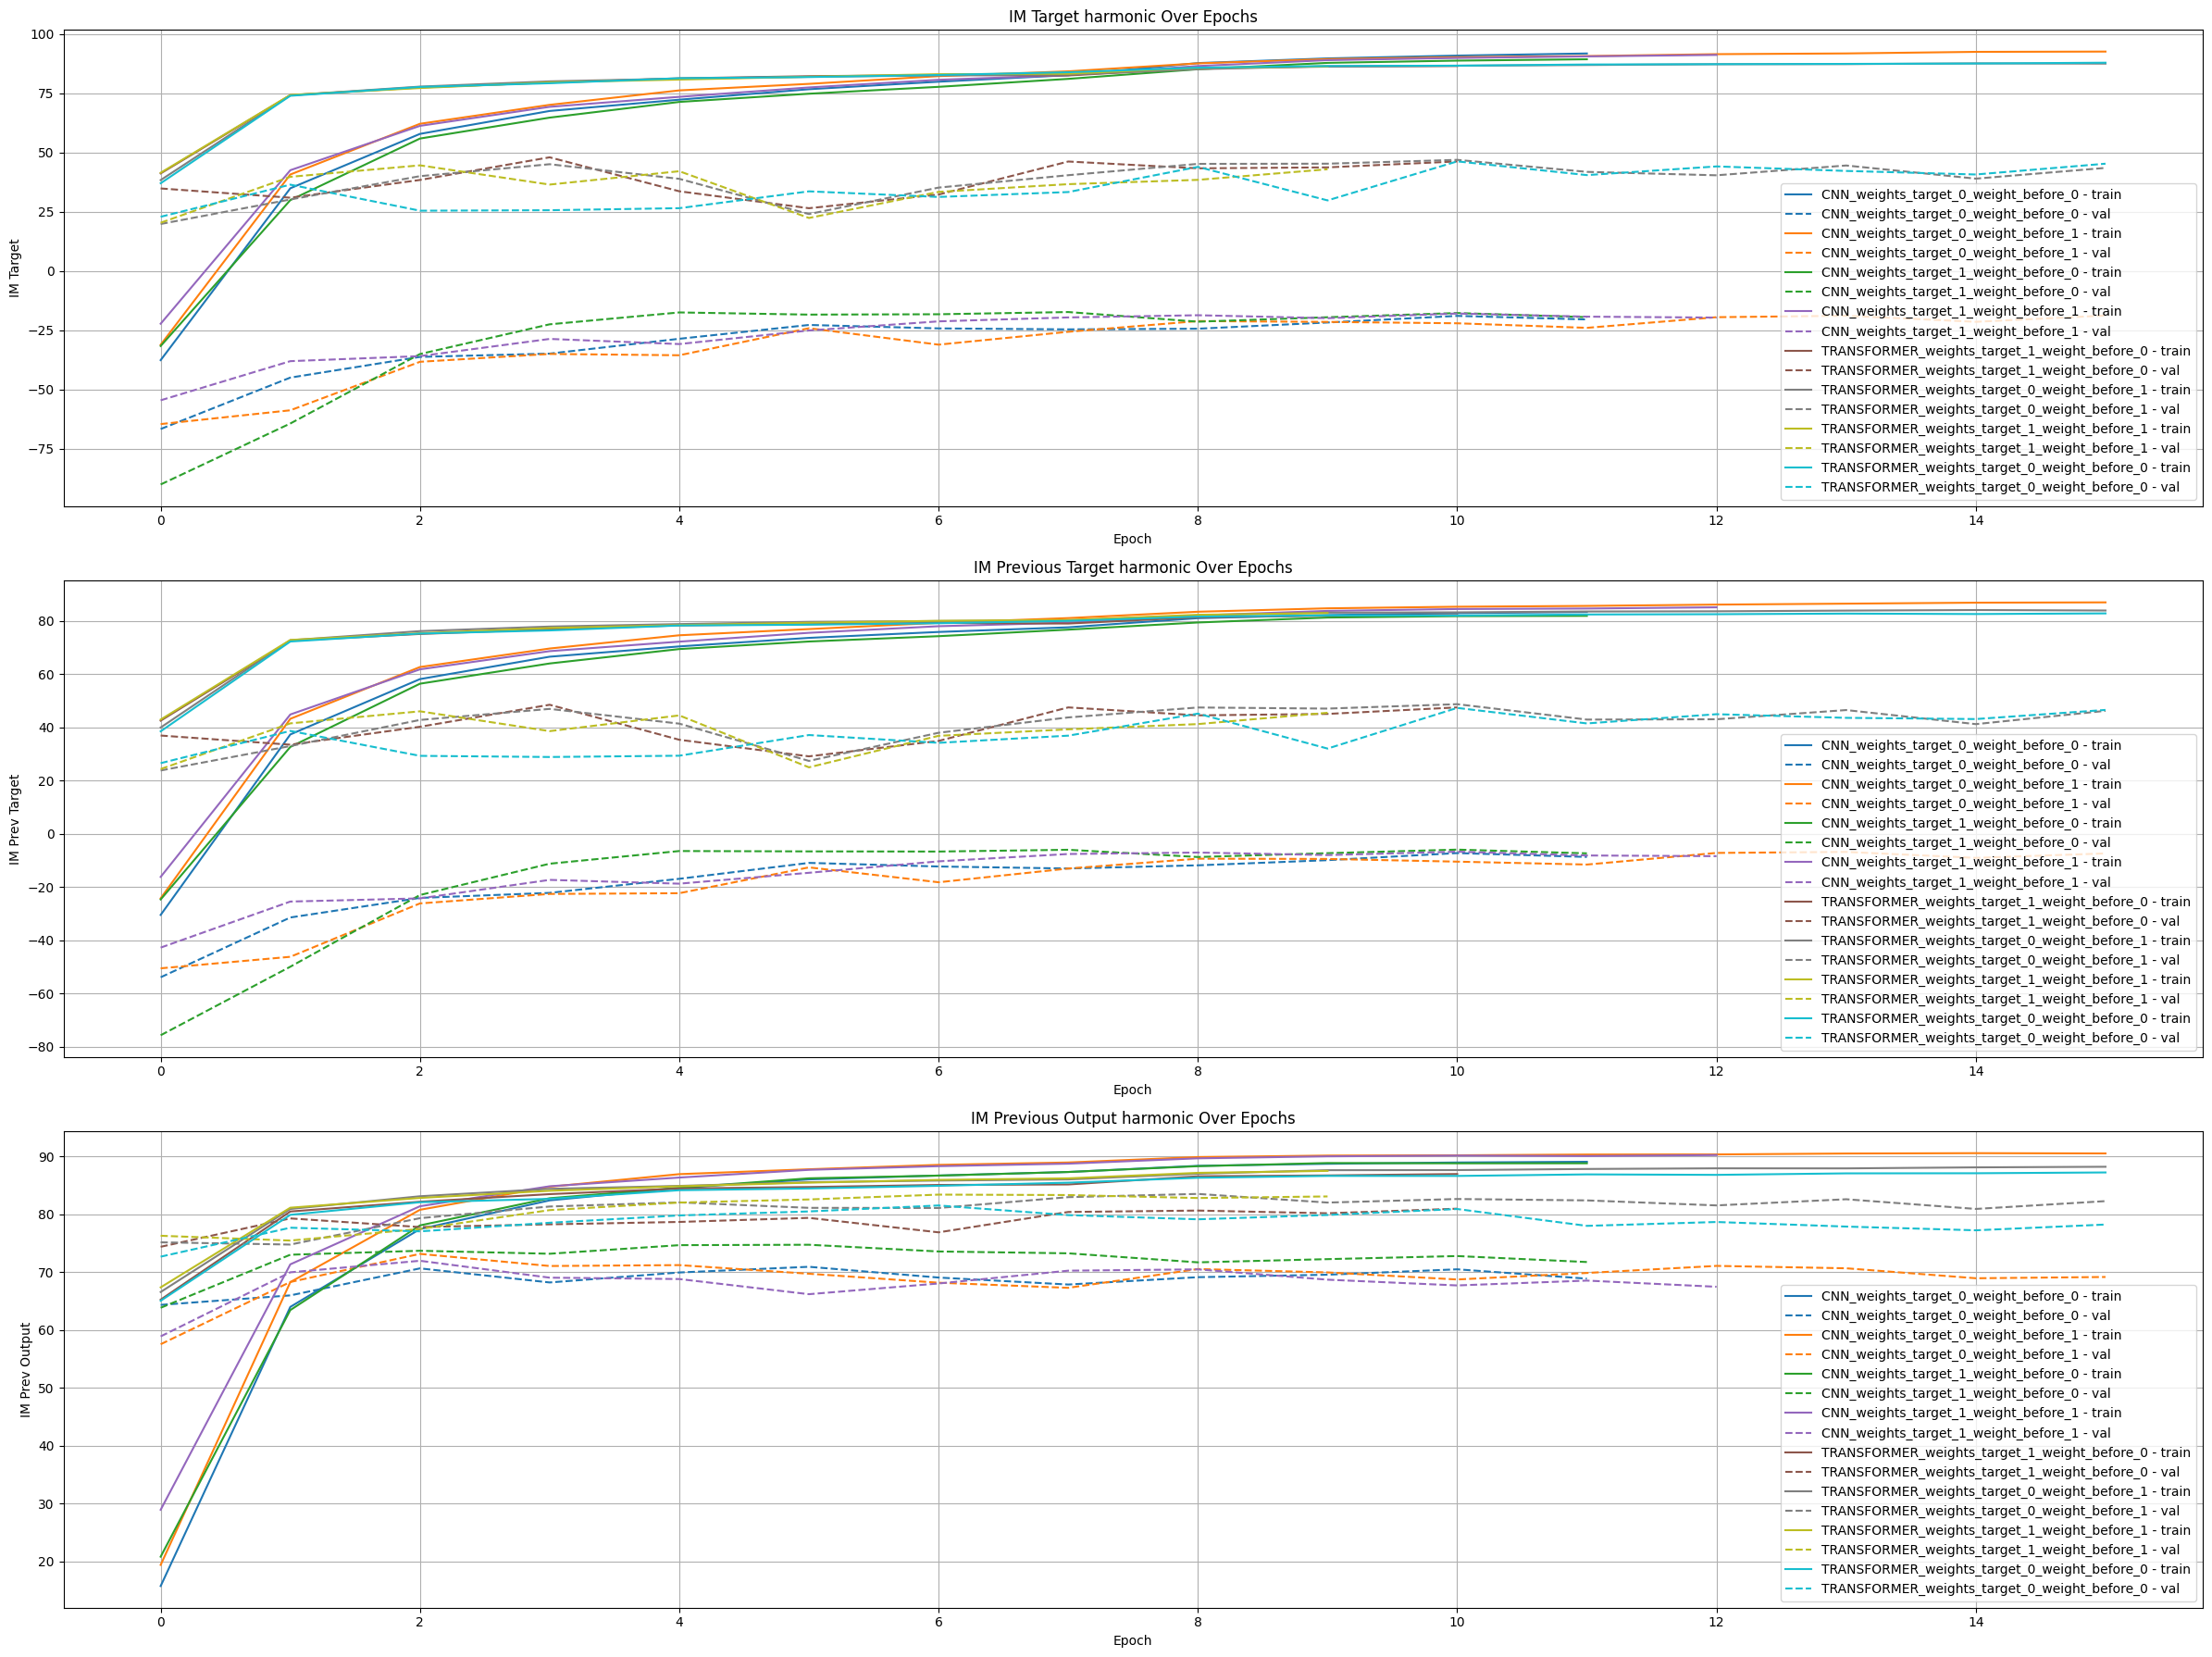

In [15]:
import matplotlib.pyplot as plt
import pandas as pd

def plot_multiple_runs(csv_paths, labels):
    """
    Plots training results from multiple CSV files on the same graph.

    Parameters:
    - csv_paths: list of paths to CSV files
    - labels: list of labels corresponding to each CSV
    """
    assert len(csv_paths) == len(labels), "Each CSV must have a corresponding label"

    plt.figure(figsize=(24, 18))

    subplot_titles = [
        ('im train target', 'im valid target', 'IM Target', 'IM Target harmonic Over Epochs'),
        ('im train prev target', 'im valid prev target', 'IM Prev Target', 'IM Previous Target harmonic Over Epochs'),
        ('im train prev output', 'im valid prev output', 'IM Prev Output', 'IM Previous Output harmonic Over Epochs')
    ]

    colors = plt.cm.get_cmap('tab10', len(labels))

    for i, (col1, col2, ylabel, title) in enumerate(subplot_titles, 1):
      plt.subplot(3, 1, i)
      for j, (path, label) in enumerate(zip(csv_paths, labels)):
          table = pd.read_csv(path, index_col=0)
          table = table.applymap(lambda x: x.detach().cpu().item() if torch.is_tensor(x) else x)
          table = table[(table.index <= 15)]
          epochs = table.index

          color = colors(j)
          plt.plot(epochs, table[col1], label=f'{label} - train', color=color, linestyle='-')
          plt.plot(epochs, table[col2], label=f'{label} - val', color=color, linestyle='--')

      plt.xlabel('Epoch')
      plt.ylabel(ylabel)
      plt.title(title)
      plt.legend()
      plt.grid(True)

    plt.tight_layout()
    plt.savefig(f"{project_path}/{folder_name}/total_graphs.png")
    plt.show()

csv_paths = [
    f"{project_path}/{folder_name}/MODEL_TYPE.CNN_weights_target_0_weight_before_0_cross_entropy.csv",
    f"{project_path}/{folder_name}/MODEL_TYPE.CNN_weights_target_0_weight_before_1_cross_entropy.csv",
    f"{project_path}/{folder_name}/MODEL_TYPE.CNN_weights_target_1_weight_before_0_cross_entropy.csv",
    f"{project_path}/{folder_name}/MODEL_TYPE.CNN_weights_target_1_weight_before_1_cross_entropy.csv",
    f"{project_path}/{folder_name}/MODEL_TYPE.TRANSFORMER_weights_target_1_weight_before_0_cross_entropy.csv",
    f"{project_path}/{folder_name}/MODEL_TYPE.TRANSFORMER_weights_target_0_weight_before_1_cross_entropy.csv",
    f"{project_path}/{folder_name}/MODEL_TYPE.TRANSFORMER_weights_target_1_weight_before_1_cross_entropy.csv",
    f"{project_path}/{folder_name}/MODEL_TYPE.TRANSFORMER_weights_target_0_weight_before_0_cross_entropy.csv"
]

labels = [
    "CNN_weights_target_0_weight_before_0",
    "CNN_weights_target_0_weight_before_1",
    "CNN_weights_target_1_weight_before_0",
    "CNN_weights_target_1_weight_before_1",
    "TRANSFORMER_weights_target_1_weight_before_0",
    "TRANSFORMER_weights_target_0_weight_before_1",
    "TRANSFORMER_weights_target_1_weight_before_1",
    "TRANSFORMER_weights_target_0_weight_before_0"
]

plot_multiple_runs(csv_paths, labels)

